In [1]:
from scipy.io import loadmat
import numpy as np


x =   loadmat("D:\cw Coureses\learning in machin and brain\home work\HW1\LMB_1404_HW1\Q2_data\IN_EAR_EEG.mat")
 
y = loadmat("D:\cw Coureses\learning in machin and brain\home work\HW1\LMB_1404_HW1\Q2_data\labels.mat")
X = x["IN_EAR_EEG"]
Y = y["label"]

print("EEG shape:", X.shape)
print("Labels shape:", Y.shape)


EEG shape: (2, 1250, 140)
Labels shape: (1, 140)


In [2]:
X = np.transpose(X, (2, 0, 1))  # -> (140, 2, 1250)
Y = Y.flatten()                 # -> (140,)

print("X shape:", X.shape)
print("Y shape:", Y.shape)

X shape: (140, 2, 1250)
Y shape: (140,)


In [3]:
unique, counts = np.unique(Y, return_counts=True)
for u, c in zip(unique, counts):
    print(f"Label {u}: {c} samples")


Label -1: 56 samples
Label 0: 28 samples
Label 1: 56 samples


In [4]:
def mixup_oversample(Xw, Yw, minority_label, target_count, lam=0.4, rng=None):
    if rng is None:
        rng = np.random.default_rng()

    Xw = list(Xw)
    Yw = list(Yw)

    idx_min = np.where(np.array(Yw) == minority_label)[0]
    current = len(idx_min)

    if current == 0:
        print("No samples of the minority class exist")
        return np.array(Xw), np.array(Yw)

    while current < target_count:
        rng = np.random.default_rng(seed=27)
        i, j = rng.choice(idx_min, size=2, replace=True)
        seg1 = Xw[i]
        seg2 = Xw[j]

        # Mixup
        new_seg = lam * seg1 + (1 - lam) * seg2

        Xw.append(new_seg)
        Yw.append(minority_label)
        current += 1

    return np.stack(Xw), np.array(Yw)


In [5]:
classes, counts = np.unique(Y, return_counts=True)
for c, k in zip(classes, counts):
    print(f"Label {c}: {k} windows")

majority_label = classes[np.argmax(counts)]
minority_label = classes[np.argmin(counts)]
max_count = counts.max()

print("Majority:", majority_label, "Minority:", minority_label)


Label -1: 56 windows
Label 0: 28 windows
Label 1: 56 windows
Majority: -1 Minority: 0


In [6]:

X_bal, Y_bal = mixup_oversample(
    X,
    Y,
    minority_label=minority_label,
    target_count=56,
    lam=0.4
)

print("Balanced shape:", X_bal.shape, Y_bal.shape)

classes_b, counts_b = np.unique(Y_bal, return_counts=True)
for c, k in zip(classes_b, counts_b):
    print(f"Label {c}: {k} windows")


Balanced shape: (168, 2, 1250) (168,)
Label -1: 56 windows
Label 0: 56 windows
Label 1: 56 windows


In [7]:
from scipy.signal import butter, filtfilt
fs=512;
def bandpass_filter(sig, low, high, fs=512, order=4):
    nyq = fs / 2
    b, a = butter(order, [low/nyq, high/nyq], btype='band')
    return filtfilt(b, a, sig)
bands = {
    "delta": (1, 4),
    "theta": (4, 8),
    "alpha": (8, 12),
    "beta": (12, 30),
    "gamma": (30, 45),
}


In [8]:
from scipy.signal import welch

def extract_features(signal, fs=512):
    N = len(signal)
    x = signal

    # 1) Mean
    mean = np.mean(x)

    # 2) Std
    std = np.std(x)

    # 3) First-order diff mean
    diff1 = np.diff(x)
    mean_diff1 = np.mean(np.abs(diff1))

    # 4) Normalized diff1
    norm_diff1 = np.mean(np.abs(diff1) / (np.abs(x[:-1]) + 1e-8))

    # 5) Second-order diff mean
    diff2 = np.diff(x, n=2)
    mean_diff2 = np.mean(np.abs(diff2))

    # 6) Normalized diff2
    norm_diff2 = np.mean(np.abs(diff2) / (np.abs(x[:-2]) + 1e-8))

    # 7) Power Spectral Density
    f, Pxx = welch(x, fs=fs, nperseg=256)
    psd = np.trapezoid(Pxx, f)

    # 8) Differential Entropy
    de = 0.5 * np.log(2 * np.pi * np.e * std**2 + 1e-8)

    return np.array([mean, std, mean_diff1, norm_diff1, 
                     mean_diff2, norm_diff2, psd, de])


In [9]:
all_features = []   # shape → (336, 80)

for sample in X_bal:       
    sample_features = []

    for ch in range(2):   # 2 channels
        sig = sample[ch]

        for name, (lo, hi) in bands.items():
            filtered = bandpass_filter(sig, lo, hi)

            feats = extract_features(filtered)   # → 8 features
            
            sample_features.extend(feats)        # append 8 features

    all_features.append(sample_features)

all_features = np.array(all_features)
print(all_features.shape)


(168, 80)


In [10]:
import numpy as np
import pandas as pd
from sklearn.model_selection import StratifiedKFold, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import make_scorer, f1_score, confusion_matrix
from sklearn.svm import SVC
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.feature_selection import SelectKBest, f_classif, mutual_info_classif
from sklearn.base import clone
import matplotlib.pyplot as plt
k_values = [ 35, 40, 45, 55,60 ,65]   
feature_selectors = {
    "Fisher": SelectKBest(score_func=f_classif, k=45),
    "MutualInfo": SelectKBest(score_func=mutual_info_classif, k=45),
}

model_builders = {
    "SVM": SVC,
    "LDA": LinearDiscriminantAnalysis,
    "DecisionTree": DecisionTreeClassifier,
    "LogReg": LogisticRegression,
}
X_feat = all_features   
y = Y_bal 

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=20)
f1_macro = make_scorer(f1_score, average="macro")

results = []

for feat_name, selector in feature_selectors.items():
    print(f"\n{'#'*70}")
    print(f"Feature selection method: {feat_name}")
    print('#'*70)

    for model_name, clf_class in model_builders.items():
        print(f"\nModel: {model_name}")

        sel = clone(selector)

        pipe = Pipeline([
            ("select", sel),
            ("scaler", StandardScaler()),
            ("clf", clf_class()),
        ])

        
        if model_name == "SVM":
            param_grid = {
                "select__k": k_values,           
                "clf__kernel": ["rbf", "linear"],
                "clf__C": [0.1, 1, 10],
                "clf__gamma": ["scale", 0.01, 0.001],
            }
        elif model_name == "LDA":
            param_grid = [
                {
                    "select__k": k_values,
                    "clf__solver": ["svd"],
                    "clf__shrinkage": [None],
                },
                {
                    "select__k": k_values,
                    "clf__solver": ["lsqr"],
                    "clf__shrinkage": ["auto", 0.1, 0.3, 0.5],
                },
            ]
        elif model_name == "DecisionTree":
            param_grid = {
                "select__k": k_values,
                "clf__max_depth": [None, 3, 5, 7],
                "clf__min_samples_split": [2, 5, 10],
                "clf__min_samples_leaf": [1, 2, 4],
            }
        elif model_name == "LogReg":
            param_grid = {
                "select__k": k_values,
                "clf__C": [0.01, 0.1, 1, 10],
                "clf__penalty": ["l2"],
                "clf__solver": ["lbfgs", "liblinear"],
                "clf__max_iter": [1000],
            }

        f1_scores_test = []

        for train_idx, test_idx in cv.split(X_feat, y):
            X_train, X_test = X_feat[train_idx], X_feat[test_idx]
            y_train, y_test = y[train_idx], y[test_idx]

            cv2 = StratifiedKFold(n_splits=5, shuffle=True, random_state=22)

            grid = GridSearchCV(
                estimator=pipe,
                param_grid=param_grid,
                cv=cv2,
                scoring=f1_macro,
                n_jobs=-1
            )
            grid.fit(X_train, y_train)

            best_model = grid.best_estimator_
            y_pred = best_model.predict(X_test)
            test_f1 = f1_score(y_test, y_pred, average="macro")
            f1_scores_test.append(test_f1)

        mean_f1 = np.mean(f1_scores_test)
        std_f1 = np.std(f1_scores_test)

        print(f"  Mean Test F1 (5-fold): {mean_f1:.4f}")
        print(f"  Standard Deviation: {std_f1:.4f}")
        print(f"  Best params (example fold): {grid.best_params_}")

        results.append({
            "feature_method": feat_name,
            "model": model_name,
            "mean_f1": mean_f1,
            "std_f1": std_f1,
            "best_params": grid.best_params_,
        })

df_final = pd.DataFrame(results)
df_final



######################################################################
Feature selection method: Fisher
######################################################################

Model: SVM
  Mean Test F1 (5-fold): 0.6747
  Standard Deviation: 0.0516
  Best params (example fold): {'clf__C': 10, 'clf__gamma': 'scale', 'clf__kernel': 'rbf', 'select__k': 55}

Model: LDA
  Mean Test F1 (5-fold): 0.5684
  Standard Deviation: 0.0475
  Best params (example fold): {'clf__shrinkage': 0.1, 'clf__solver': 'lsqr', 'select__k': 55}

Model: DecisionTree
  Mean Test F1 (5-fold): 0.4881
  Standard Deviation: 0.0819
  Best params (example fold): {'clf__max_depth': None, 'clf__min_samples_leaf': 1, 'clf__min_samples_split': 5, 'select__k': 35}

Model: LogReg


c:\Users\aivic\anaconda3\envs\dl_env\lib\site-packages\sklearn\linear_model\_logistic.py:1296: FutureWarning: Using the 'liblinear' solver for multiclass classification is deprecated. An error will be raised in 1.8. Either use another solver which supports the multinomial loss or wrap the estimator in a OneVsRestClassifier to keep applying a one-versus-rest scheme.
  warnings.warn(
c:\Users\aivic\anaconda3\envs\dl_env\lib\site-packages\sklearn\linear_model\_logistic.py:1296: FutureWarning: Using the 'liblinear' solver for multiclass classification is deprecated. An error will be raised in 1.8. Either use another solver which supports the multinomial loss or wrap the estimator in a OneVsRestClassifier to keep applying a one-versus-rest scheme.
  warnings.warn(
c:\Users\aivic\anaconda3\envs\dl_env\lib\site-packages\sklearn\linear_model\_logistic.py:1296: FutureWarning: Using the 'liblinear' solver for multiclass classification is deprecated. An error will be raised in 1.8. Either use ano

  Mean Test F1 (5-fold): 0.6065
  Standard Deviation: 0.0785
  Best params (example fold): {'clf__C': 10, 'clf__max_iter': 1000, 'clf__penalty': 'l2', 'clf__solver': 'lbfgs', 'select__k': 45}

######################################################################
Feature selection method: MutualInfo
######################################################################

Model: SVM
  Mean Test F1 (5-fold): 0.6022
  Standard Deviation: 0.0769
  Best params (example fold): {'clf__C': 10, 'clf__gamma': 0.001, 'clf__kernel': 'rbf', 'select__k': 35}

Model: LDA
  Mean Test F1 (5-fold): 0.5749
  Standard Deviation: 0.0802
  Best params (example fold): {'clf__shrinkage': 0.1, 'clf__solver': 'lsqr', 'select__k': 60}

Model: DecisionTree
  Mean Test F1 (5-fold): 0.4902
  Standard Deviation: 0.0942
  Best params (example fold): {'clf__max_depth': 5, 'clf__min_samples_leaf': 1, 'clf__min_samples_split': 2, 'select__k': 40}

Model: LogReg


c:\Users\aivic\anaconda3\envs\dl_env\lib\site-packages\sklearn\linear_model\_logistic.py:1296: FutureWarning: Using the 'liblinear' solver for multiclass classification is deprecated. An error will be raised in 1.8. Either use another solver which supports the multinomial loss or wrap the estimator in a OneVsRestClassifier to keep applying a one-versus-rest scheme.
  warnings.warn(
c:\Users\aivic\anaconda3\envs\dl_env\lib\site-packages\sklearn\linear_model\_logistic.py:1296: FutureWarning: Using the 'liblinear' solver for multiclass classification is deprecated. An error will be raised in 1.8. Either use another solver which supports the multinomial loss or wrap the estimator in a OneVsRestClassifier to keep applying a one-versus-rest scheme.
  warnings.warn(
c:\Users\aivic\anaconda3\envs\dl_env\lib\site-packages\sklearn\linear_model\_logistic.py:1296: FutureWarning: Using the 'liblinear' solver for multiclass classification is deprecated. An error will be raised in 1.8. Either use ano

  Mean Test F1 (5-fold): 0.6085
  Standard Deviation: 0.0730
  Best params (example fold): {'clf__C': 0.01, 'clf__max_iter': 1000, 'clf__penalty': 'l2', 'clf__solver': 'lbfgs', 'select__k': 60}


,feature_method,model,mean_f1,std_f1,best_params
0,Fisher,SVM,0.674678,0.051571,"{'clf__C': 10, 'clf__gamma': 'scale', 'clf__ke..."
1,Fisher,LDA,0.568403,0.047452,"{'clf__shrinkage': 0.1, 'clf__solver': 'lsqr',..."
2,Fisher,DecisionTree,0.488133,0.081939,"{'clf__max_depth': None, 'clf__min_samples_lea..."
3,Fisher,LogReg,0.606458,0.078510,"{'clf__C': 10, 'clf__max_iter': 1000, 'clf__pe..."
4,MutualInfo,SVM,0.602237,0.076850,"{'clf__C': 10, 'clf__gamma': 0.001, 'clf__kern..."
5,MutualInfo,LDA,0.574885,0.080206,"{'clf__shrinkage': 0.1, 'clf__solver': 'lsqr',..."
6,MutualInfo,DecisionTree,0.490152,0.094230,"{'clf__max_depth': 5, 'clf__min_samples_leaf':..."
7,MutualInfo,LogReg,0.608506,0.073044,"{'clf__C': 0.01, 'clf__max_iter': 1000, 'clf__..."



######################################################################
Feature selection method: Fisher
######################################################################

Model: SVM
  Mean Test F1: 0.6747  ± 0.0516
  Best params (example fold): {'clf__C': 10, 'clf__gamma': 'scale', 'clf__kernel': 'rbf', 'select__k': 55}

Model: LDA
  Mean Test F1: 0.5684  ± 0.0475
  Best params (example fold): {'clf__shrinkage': 0.1, 'clf__solver': 'lsqr', 'select__k': 55}

Model: DecisionTree
  Mean Test F1: 0.5133  ± 0.0404
  Best params (example fold): {'clf__max_depth': None, 'clf__min_samples_leaf': 4, 'clf__min_samples_split': 10, 'select__k': 55}

Model: LogReg


c:\Users\aivic\anaconda3\envs\dl_env\lib\site-packages\sklearn\linear_model\_logistic.py:1296: FutureWarning: Using the 'liblinear' solver for multiclass classification is deprecated. An error will be raised in 1.8. Either use another solver which supports the multinomial loss or wrap the estimator in a OneVsRestClassifier to keep applying a one-versus-rest scheme.
  warnings.warn(
c:\Users\aivic\anaconda3\envs\dl_env\lib\site-packages\sklearn\linear_model\_logistic.py:1296: FutureWarning: Using the 'liblinear' solver for multiclass classification is deprecated. An error will be raised in 1.8. Either use another solver which supports the multinomial loss or wrap the estimator in a OneVsRestClassifier to keep applying a one-versus-rest scheme.
  warnings.warn(
c:\Users\aivic\anaconda3\envs\dl_env\lib\site-packages\sklearn\linear_model\_logistic.py:1296: FutureWarning: Using the 'liblinear' solver for multiclass classification is deprecated. An error will be raised in 1.8. Either use ano

  Mean Test F1: 0.6065  ± 0.0785
  Best params (example fold): {'clf__C': 10, 'clf__max_iter': 1000, 'clf__penalty': 'l2', 'clf__solver': 'lbfgs', 'select__k': 45}

######################################################################
Feature selection method: MutualInfo
######################################################################

Model: SVM
  Mean Test F1: 0.6022  ± 0.0769
  Best params (example fold): {'clf__C': 10, 'clf__gamma': 0.001, 'clf__kernel': 'rbf', 'select__k': 35}

Model: LDA
  Mean Test F1: 0.5749  ± 0.0802
  Best params (example fold): {'clf__shrinkage': 0.1, 'clf__solver': 'lsqr', 'select__k': 60}

Model: DecisionTree
  Mean Test F1: 0.5081  ± 0.1058
  Best params (example fold): {'clf__max_depth': 5, 'clf__min_samples_leaf': 2, 'clf__min_samples_split': 2, 'select__k': 55}

Model: LogReg


c:\Users\aivic\anaconda3\envs\dl_env\lib\site-packages\sklearn\linear_model\_logistic.py:1296: FutureWarning: Using the 'liblinear' solver for multiclass classification is deprecated. An error will be raised in 1.8. Either use another solver which supports the multinomial loss or wrap the estimator in a OneVsRestClassifier to keep applying a one-versus-rest scheme.
  warnings.warn(
c:\Users\aivic\anaconda3\envs\dl_env\lib\site-packages\sklearn\linear_model\_logistic.py:1296: FutureWarning: Using the 'liblinear' solver for multiclass classification is deprecated. An error will be raised in 1.8. Either use another solver which supports the multinomial loss or wrap the estimator in a OneVsRestClassifier to keep applying a one-versus-rest scheme.
  warnings.warn(
c:\Users\aivic\anaconda3\envs\dl_env\lib\site-packages\sklearn\linear_model\_logistic.py:1296: FutureWarning: Using the 'liblinear' solver for multiclass classification is deprecated. An error will be raised in 1.8. Either use ano

  Mean Test F1: 0.6085  ± 0.0730
  Best params (example fold): {'clf__C': 0.01, 'clf__max_iter': 1000, 'clf__penalty': 'l2', 'clf__solver': 'lbfgs', 'select__k': 60}
  feature_method         model   mean_f1    std_f1
0         Fisher           SVM  0.674678  0.051571
1         Fisher           LDA  0.568403  0.047452
2         Fisher  DecisionTree  0.513333  0.040383
3         Fisher        LogReg  0.606458  0.078510
4     MutualInfo           SVM  0.602237  0.076850
5     MutualInfo           LDA  0.574885  0.080206
6     MutualInfo  DecisionTree  0.508137  0.105788
7     MutualInfo        LogReg  0.608506  0.073044


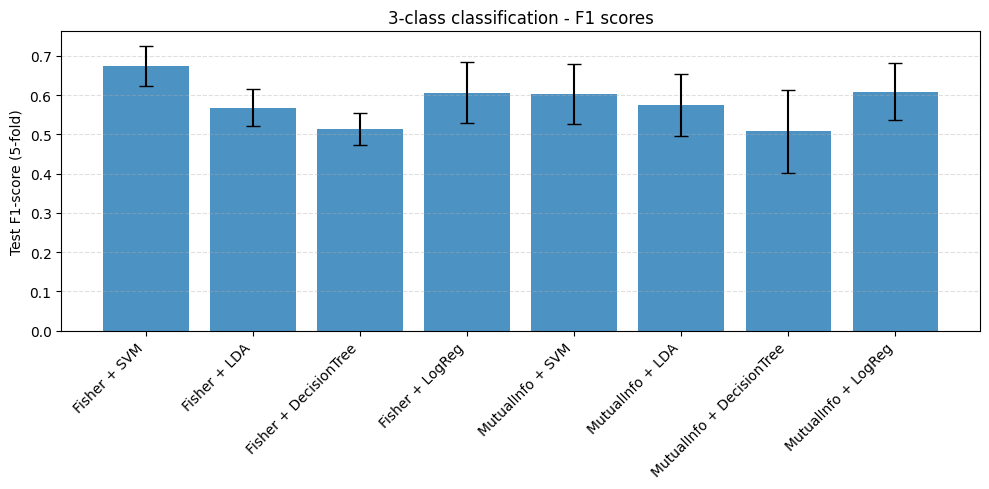

C:\Users\aivic\AppData\Local\Temp\ipykernel_10792\387134100.py:180: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.9, 1])


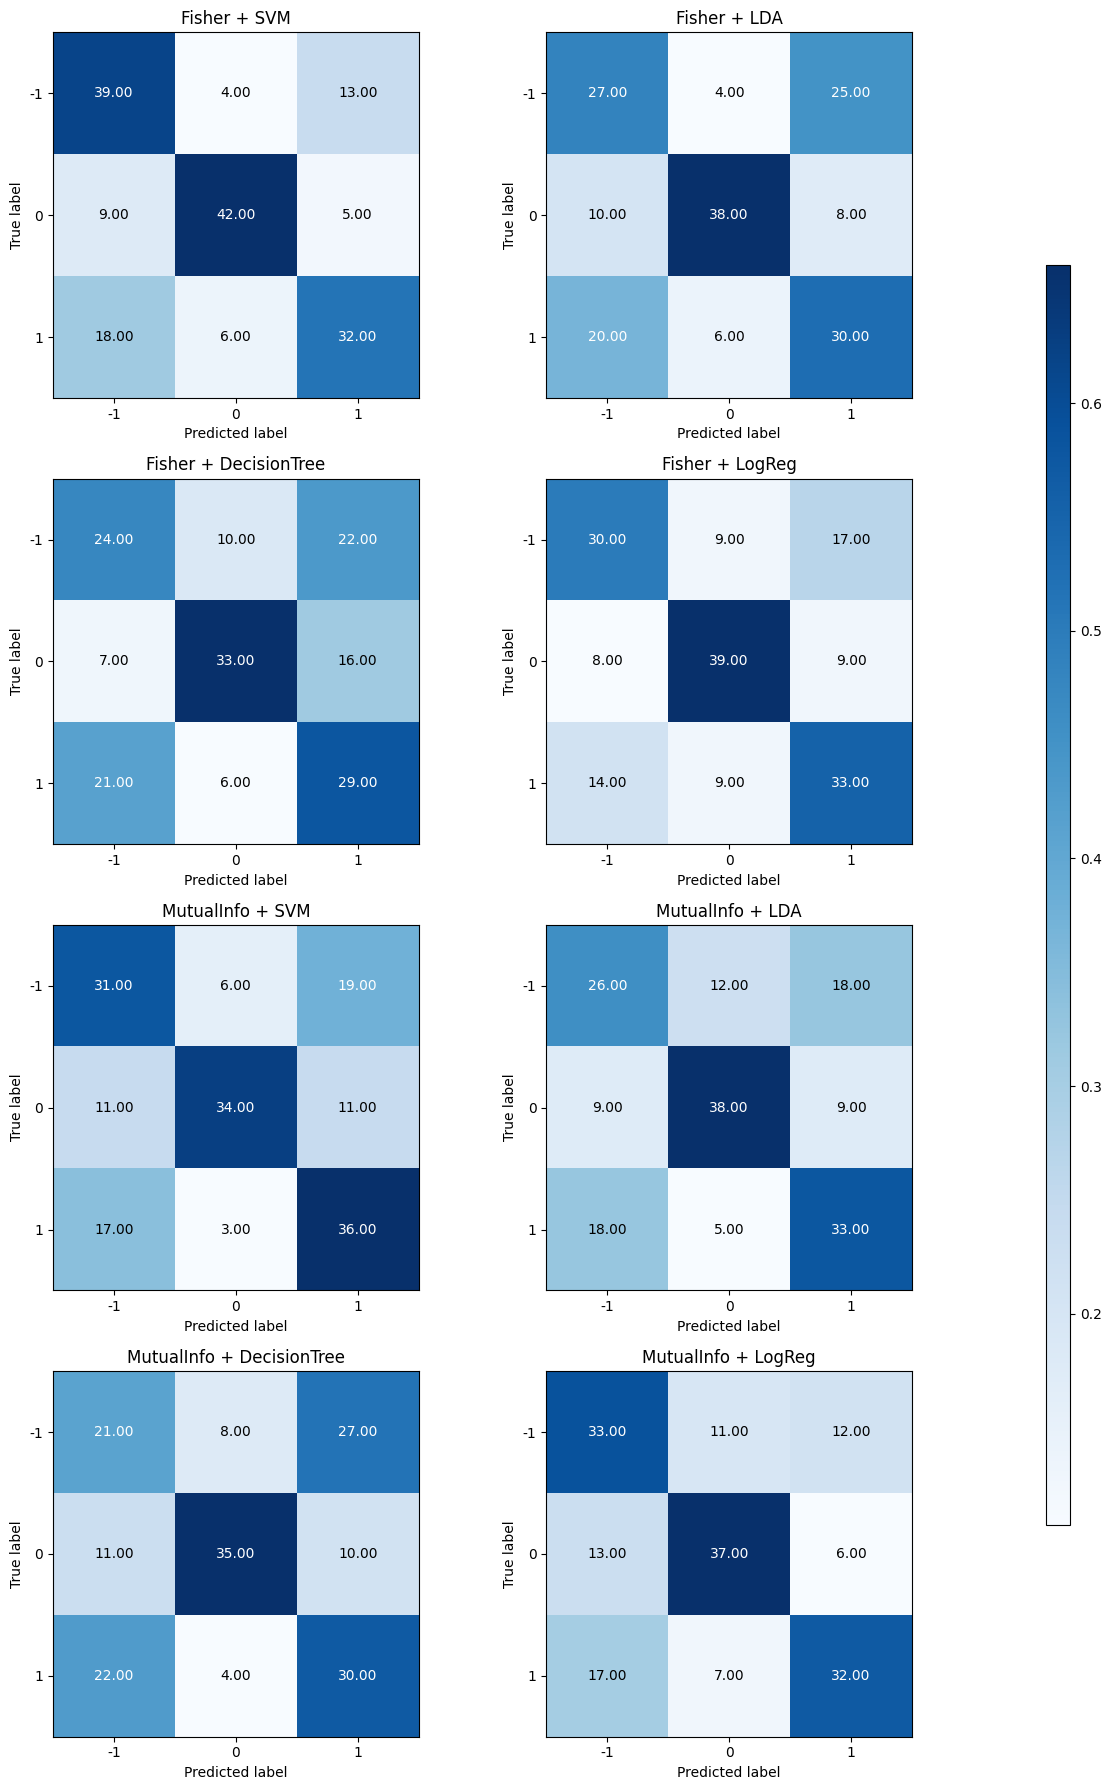

In [11]:
import numpy as np
import pandas as pd
from sklearn.model_selection import StratifiedKFold, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import make_scorer, f1_score, confusion_matrix
from sklearn.svm import SVC
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.feature_selection import SelectKBest, f_classif, mutual_info_classif
from sklearn.base import clone
import matplotlib.pyplot as plt
k_values = [ 35, 40, 45, 55,60 ,65]   # هرچی خواستی این‌جا بازی کن
feature_selectors = {
    "Fisher": SelectKBest(score_func=f_classif, k=45),
    "MutualInfo": SelectKBest(score_func=mutual_info_classif, k=45),
}

model_builders = {
    "SVM": SVC,
    "LDA": LinearDiscriminantAnalysis,
    "DecisionTree": DecisionTreeClassifier,
    "LogReg": LogisticRegression,
}
X_feat = all_features 
y = Y_bal  

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=20)
f1_macro = make_scorer(f1_score, average="macro")

results_comb = []

for feat_name, selector in feature_selectors.items():
    print(f"\n{'#'*70}")
    print(f"Feature selection method: {feat_name}")
    print('#'*70)

    for model_name, clf_class in model_builders.items():
        print(f"\nModel: {model_name}")

        sel = clone(selector)

        pipe = Pipeline([
            ("select", sel),
            ("scaler", StandardScaler()),
            ("clf", clf_class()),
        ])

        
        if model_name == "SVM":
            param_grid = {
                "select__k": k_values,          
                "clf__kernel": ["rbf", "linear"],
                "clf__C": [0.1, 1, 10],
                "clf__gamma": ["scale", 0.01, 0.001],
            }
        elif model_name == "LDA":
            param_grid = [
                {
                    "select__k": k_values,
                    "clf__solver": ["svd"],
                    "clf__shrinkage": [None],
                },
                {
                    "select__k": k_values,
                    "clf__solver": ["lsqr"],
                    "clf__shrinkage": ["auto", 0.1, 0.3, 0.5],
                },
            ]
        elif model_name == "DecisionTree":
            param_grid = {
                "select__k": k_values,
                "clf__max_depth": [None, 3, 5, 7],
                "clf__min_samples_split": [2, 5, 10],
                "clf__min_samples_leaf": [1, 2, 4],
            }
        elif model_name == "LogReg":
            param_grid = {
                "select__k": k_values,
                "clf__C": [0.01, 0.1, 1, 10],
                "clf__penalty": ["l2"],
                "clf__solver": ["lbfgs", "liblinear"],
                "clf__max_iter": [1000],
            }

        f1_scores_test = []
        y_pred_list = []
        y_test_list = []
        for train_idx, test_idx in cv.split(X_feat, y):
            X_train, X_test = X_feat[train_idx], X_feat[test_idx]
            y_train, y_test = y[train_idx], y[test_idx]

            cv2 = StratifiedKFold(n_splits=5, shuffle=True, random_state=22)

            grid = GridSearchCV(
                estimator=pipe,
                param_grid=param_grid,
                cv=cv2,
                scoring=f1_macro,
                n_jobs=-1
            )
            
            grid.fit(X_train, y_train)

            best_model = grid.best_estimator_
            y_pred = best_model.predict(X_test)

            y_pred_list.append(y_pred)
            y_test_list.append(y_test)

            test_f1 = f1_score(y_test, y_pred, average="macro")
            f1_scores_test.append(test_f1)

        mean_f1 = np.mean(f1_scores_test)
        std_f1 = np.std(f1_scores_test)

        print(f"  Mean Test F1: {mean_f1:.4f}  ± {std_f1:.4f}")
        print(f"  Best params (example fold): {grid.best_params_}")


        item = {
            "feature_method": feat_name,
            "model": model_name,
            "mean_f1": mean_f1,
            "std_f1": std_f1,
            "best_params": grid.best_params_,
            "y_pred": y_pred_list,
            "y_test": y_test_list,
        }
        results_comb.append(item)


df_comb = pd.DataFrame(results_comb)
print(df_comb[["feature_method", "model", "mean_f1", "std_f1"]])


fig, ax = plt.subplots(figsize=(10, 5))
idx = np.arange(len(df_comb))
ax.bar(idx, df_comb["mean_f1"], yerr=df_comb["std_f1"], alpha=0.8, capsize=5)
ax.set_xticks(idx)
ax.set_xticklabels(df_comb["feature_method"] + " + " + df_comb["model"], rotation=45, ha="right")
ax.set_ylabel("Test F1-score (5-fold)")
ax.set_title("3-class classification - F1 scores")
ax.grid(axis="y", linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()

labels = np.unique(y)

rows, cols = 4, 2     
fig, axes = plt.subplots(rows, cols, figsize=(12, 18))

for ax, item in zip(axes.ravel(), results_comb):
    y_pred_all = np.concatenate(item["y_pred"])
    y_test_all = np.concatenate(item["y_test"])

    cm = confusion_matrix(y_test_all, y_pred_all, labels=labels)
    cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

    im = ax.imshow(cm_norm, interpolation='nearest', cmap='Blues')
    ax.set_title(f"{item['feature_method']} + {item['model']}")

    ax.set_xticks(np.arange(len(labels)))
    ax.set_yticks(np.arange(len(labels)))
    ax.set_xticklabels(labels)
    ax.set_yticklabels(labels)

    ax.set_xlabel("Predicted label")
    ax.set_ylabel("True label")

    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            val = cm[i, j]
            ax.text(j, i, f"{val:.2f}", ha="center", va="center",
                    color="white" if val > cm.max() / 2 else "black")

cbar_ax = fig.add_axes([0.92, 0.15, 0.02, 0.7])
fig.colorbar(im, cax=cbar_ax)
plt.tight_layout(rect=[0, 0, 0.9, 1])
plt.show()
